# Analisis Konsentrasi Polutan — Kecamatan Sokobanah

Notebook ini menganalisis 4 polutan (CO, NO2, SO2, CH4) di Kecamatan Sokobanah: imputasi data hilang, ekstraksi 68 fitur TSFEL, lalu deteksi outlier **antar-anggota kelompok** memakai K-Means (setara dengan alur KNIME) dan, bila terpasang, PyOD.

### Tahapan
1. Import & pengecekan pustaka
2. Akuisisi data **citra satelit Sentinel-5P asli** via OpenEO (365 hari per polutan)
3. Penanganan *missing values* — **imputasi polinomial** (menggantikan imputasi linier)
4. Ekstraksi 68 fitur TSFEL — **memakai dataset hasil imputasi polinomial**
5. Analisis kemiripan pola antar kuartal (cosine similarity & Pearson)
6. Deteksi outlier **K-Means** pada tabel fitur seluruh anggota (file Excel rekan) — Python + panduan KNIME
7. Dokumentasi fitur TSFEL

In [ ]:
import sys, os, subprocess, importlib.util, warnings, inspect, zlib, time
warnings.filterwarnings("ignore", category=FutureWarning)

PASANG_OTOMATIS = globals().get("PASANG_OTOMATIS", True)   # False = jangan mencoba pip install


def pastikan(paket, modul=None):
    """Pasang paket bila belum ada. Mengembalikan True jika modul bisa diimpor."""
    modul = modul or paket
    if importlib.util.find_spec(modul) is None and PASANG_OTOMATIS:
        print(f"Memasang {paket} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--prefer-binary", paket])
        except Exception as e:
            print(f"  Gagal memasang {paket}: {e}")
    return importlib.util.find_spec(modul) is not None


# Wajib
for p, m in {"pandas": "pandas", "numpy": "numpy", "scipy": "scipy", "scikit-learn": "sklearn",
             "matplotlib": "matplotlib", "seaborn": "seaborn", "openpyxl": "openpyxl"}.items():
    if not pastikan(p, m):
        raise ImportError(f"Library wajib '{p}' tidak tersedia. Pasang manual: pip install {p}")

# Opsional (notebook tetap jalan tanpa ini)
ADA_TSFEL = pastikan("tsfel")
ADA_PYOD = pastikan("pyod")
ADA_FOLIUM = pastikan("folium")
ADA_GEE = pastikan("earthengine-api", "ee")   # metode utama: Google Earth Engine
ADA_OPENEO = pastikan("openeo")        # wajib untuk mengunduh citra satelit Sentinel-5P

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except Exception:
    display = print

# TSFEL asli: dipakai langsung per-fungsi agar nilainya sama persis dengan data rekan
tsfel_features = None
if ADA_TSFEL:
    try:
        from tsfel.feature_extraction import features as tsfel_features
    except Exception as e:
        print("TSFEL terpasang tetapi modul fitur gagal diimpor:", e)

# PyOD (opsional): dipakai sebagai pembanding berbasis K-Means (CBLOF)
CBLOF = None
if ADA_PYOD:
    try:
        from pyod.models.cblof import CBLOF
    except Exception as e:
        print("PyOD terpasang tetapi gagal diimpor (dilewati):", e)

pd.set_option("display.max_columns", 20)
print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__, "| numpy:", np.__version__)
print("TSFEL asli  :", "AKTIF" if tsfel_features is not None else "TIDAK TERSEDIA -> fitur dihitung manual (aproksimasi)")
print("Earth Engine :", "AKTIF" if ADA_GEE else "TIDAK TERPASANG -> jalankan: pip install earthengine-api")
print("OpenEO       :", "AKTIF" if ADA_OPENEO else "TIDAK TERPASANG -> jalankan: pip install openeo")
print("PyOD (CBLOF):", "AKTIF" if CBLOF is not None else "tidak tersedia -> hanya K-Means scikit-learn")

Python : 3.13.15
pandas : 2.2.3 | numpy: 2.1.3
TSFEL asli  : AKTIF
Earth Engine : AKTIF
OpenEO       : AKTIF
PyOD (CBLOF): AKTIF


In [ ]:
# Peta wilayah kajian (opsional; dilewati jika folium tidak ada)
KECAMATAN = "Sokobanah"
bbox_sokobanah = {"west": 113.25, "south": -6.95, "east": 113.36, "north": -6.86}

peta_sokobanah = None
if ADA_FOLIUM:
    import folium
    pusat_lat = (bbox_sokobanah["south"] + bbox_sokobanah["north"]) / 2
    pusat_lon = (bbox_sokobanah["west"] + bbox_sokobanah["east"]) / 2
    peta_sokobanah = folium.Map(location=[pusat_lat, pusat_lon], zoom_start=13, tiles="OpenStreetMap")
    folium.Rectangle(
        bounds=[[bbox_sokobanah["south"], bbox_sokobanah["west"]],
                [bbox_sokobanah["north"], bbox_sokobanah["east"]]],
        color="red", fill=True, fill_opacity=0.2,
        tooltip=f"Wilayah kajian: Kecamatan {KECAMATAN}",
    ).add_to(peta_sokobanah)
    folium.Marker([pusat_lat, pusat_lon], popup=KECAMATAN, icon=folium.Icon(color="red")).add_to(peta_sokobanah)
peta_sokobanah

## Langkah 1 — Akuisisi Data Citra Satelit Sentinel-5P (data asli)

Data diambil dari **citra satelit Sentinel-5P TROPOMI (Level-2)** melalui **OpenEO – Copernicus Data Space**, koleksi `SENTINEL_5P_L2`, band `CO`, `NO2`, `SO2`, `CH4`. Untuk tiap hari, nilai piksel dirata-rata di dalam kotak wilayah Kecamatan Sokobanah (*spatial mean*).

| Polutan | Satuan |
|---|---|
| CO, NO2, SO2 | mol/m² |
| CH4 | ppb (rasio campuran kolom) |

Alur sumber data:
1. Jika `data/polutan_sokobanah.csv` sudah ada → dipakai (hasil unduhan sebelumnya, sehingga tidak perlu login ulang dan hasil konsisten).
2. Jika belum ada → unduh via OpenEO (login Copernicus lewat browser, gratis) lalu simpan ke file tersebut.
3. Jika keduanya gagal → **notebook berhenti dengan pesan jelas**. Tidak ada lagi data simulasi.

Hari tanpa data (awan / tidak ada lintasan satelit) tercatat sebagai kosong dan ditangani di Langkah 2.


> **Catatan perbaikan:** koleksi `SENTINEL_5P_L2` (via Sentinel Hub) gagal membaca beberapa file NRT Oktober 2025 (error 500 "Illegal request" dari server Copernicus). Unduhan sekarang memakai koleksi per-polutan `SENTINEL5P_L2_<polutan>` terlebih dahulu, dengan pemetaan nama band yang benar (mis. `nitrogendioxide_tropospheric_column` untuk NO2). Alternatif: `METODE_UNDUH = "GEE"` memakai Google Earth Engine (`COPERNICUS/S5P/OFFL/L3_*`).

In [ ]:
# =========================================================
# KONFIGURASI
# =========================================================
POLLUTANS = ["CO", "NO2", "SO2", "CH4"]
start_date = "2025-08-24"
end_date = "2026-08-23"
PAKAI_DATA_LIVE = True    # True = boleh mengunduh bila CSV belum ada
METODE_UNDUH = "OPENEO"   # "OPENEO" (Copernicus, sudah diperbaiki) atau "GEE" (Google Earth Engine, alternatif)
GEE_PROJECT = ""          # isi ID project Google Cloud Anda (mis. "proyek-saya-123456"); wajib untuk Earth Engine

DATA_DIR = os.path.join(os.getcwd(), "data")
PATH_CSV = os.path.join(DATA_DIR, "polutan_sokobanah.csv")


def ambil_nilai_skalar(v):
    """Bongkar list/tuple/array secara rekursif sampai didapat satu float (atau None)."""
    while isinstance(v, (list, tuple, np.ndarray)):
        if len(v) == 0:
            return None
        v = v[0]
    if v is None:
        return None
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def baca_csv(path):
    df = pd.read_csv(path)
    if "tanggal" not in df.columns:
        raise ValueError(f"{path} harus punya kolom 'tanggal'.")
    kolom = [p for p in POLLUTANS if p in df.columns]
    if not kolom:
        raise ValueError(f"{path} tidak memuat kolom polutan {POLLUTANS}.")
    df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")
    df = df.dropna(subset=["tanggal"]).sort_values("tanggal").drop_duplicates("tanggal").set_index("tanggal")
    df = df[kolom].reindex(pd.date_range(start_date, end_date, freq="D"))
    df.index.name = "tanggal"
    return df.reset_index()


def _pesan(e):
    return f"{type(e).__name__}: {str(e)[:500]}"


def _potongan_bulanan(mulai, selesai):
    """Pecah rentang waktu jadi per-bulan [awal, akhir) agar tiap permintaan ringan."""
    awal = pd.Timestamp(mulai)
    akhir = pd.Timestamp(selesai) + pd.Timedelta(days=1)       # batas akhir eksklusif
    hasil = []
    while awal < akhir:
        nxt = min((awal + pd.offsets.MonthBegin(1)).normalize(), akhir)
        hasil.append((awal.strftime("%Y-%m-%d"), nxt.strftime("%Y-%m-%d")))
        awal = nxt
    return hasil


# Nama band asli di koleksi SENTINEL5P_L2_<polutan> (CDSE). Urutan = prioritas.
BAND_KATA_KUNCI = {
    "CO":  ["carbonmonoxide_total_column", "carbonmonoxide"],
    "NO2": ["nitrogendioxide_tropospheric_column", "nitrogendioxide_total_column", "nitrogendioxide"],
    "SO2": ["sulfurdioxide_total_vertical_column", "sulfurdioxide_total_column", "sulfurdioxide"],
    "CH4": ["methane_mixing_ratio_bias_corrected", "methane_mixing_ratio", "methane"],
}
_BAND_DIKECUALIKAN = ("precision", "qa_value", "apriori", "averaging", "stratospheric", "kernel")


def _nama_band(conn, koleksi, band):
    """Cari nama band yang benar di koleksi berdasarkan kata kunci per polutan."""
    meta = conn.describe_collection(koleksi)
    nama = []
    try:
        nama = [b["name"] for b in meta.get("summaries", {}).get("eo:bands", [])]
    except Exception:
        pass
    if not nama:
        try:
            nama = list(meta["cube:dimensions"]["bands"]["values"])
        except Exception:
            pass
    layak = [n for n in nama if not any(x in n.lower() for x in _BAND_DIKECUALIKAN)]
    for kata in BAND_KATA_KUNCI.get(band, [band.lower()]):
        for n in layak:
            if kata in n.lower():
                return n
    raise ValueError(f"Band untuk {band} tidak ditemukan di {koleksi}. Band tersedia: {nama}")


def _unduh_rentang(conn, koleksi, nama_band, extent, poligon, t0, t1, hari_gagal,
                   max_retries=2, retry_delay=3):
    """Unduh rata-rata harian untuk [t0, t1). Jika gagal, rentang DIBELAH DUA berulang sampai tingkat
    1 hari; hari yang tetap gagal (data rusak di server) dilewati -> NaN, diimputasi di Langkah 2."""
    galat = None
    for percobaan in range(max_retries):
        try:
            cube = conn.load_collection(
                koleksi, spatial_extent={**extent, "crs": "EPSG:4326"},
                temporal_extent=[t0, t1], bands=[nama_band])
            harian = cube.aggregate_temporal_period(reducer="mean", period="day")
            res = harian.aggregate_spatial(geometries=poligon, reducer="mean").execute()
            return pd.Series({pd.to_datetime(str(k)[:10]): ambil_nilai_skalar(v) for k, v in res.items()},
                             dtype=float)
        except Exception as e:
            galat = e
            if percobaan < max_retries - 1:
                time.sleep(retry_delay)
    n_hari = (pd.Timestamp(t1) - pd.Timestamp(t0)).days
    if n_hari <= 1:
        hari_gagal.append(t0)
        print(f"      hari {t0} dilewati (NaN) -> {_pesan(galat)[:150]}")
        return pd.Series(dtype=float)
    tengah = (pd.Timestamp(t0) + pd.Timedelta(days=n_hari // 2)).strftime("%Y-%m-%d")
    print(f"      [{t0} s.d. {t1}) gagal -> dibelah di {tengah}")
    kiri = _unduh_rentang(conn, koleksi, nama_band, extent, poligon, t0, tengah, hari_gagal, max_retries, retry_delay)
    kanan = _unduh_rentang(conn, koleksi, nama_band, extent, poligon, tengah, t1, hari_gagal, max_retries, retry_delay)
    return pd.concat([kiri, kanan])


def _unduh_satu_band(conn, koleksi, nama_band, extent, poligon, **kw):
    """Unduh rata-rata harian satu band, per-bulan, tahan terhadap hari yang rusak di server."""
    bagian, hari_gagal = [], []
    for t0, t1 in _potongan_bulanan(start_date, end_date):
        bagian.append(_unduh_rentang(conn, koleksi, nama_band, extent, poligon, t0, t1, hari_gagal))
    total_hari = len(pd.date_range(start_date, end_date, freq="D"))
    if len(hari_gagal) > 0.5 * total_hari:        # koleksi praktis rusak -> biarkan koleksi cadangan dicoba
        raise RuntimeError(f"{koleksi}: {len(hari_gagal)}/{total_hari} hari gagal diunduh.")
    if hari_gagal:
        print(f"    PERHATIAN: {len(hari_gagal)} hari gagal diunduh dan dijadikan NaN: {hari_gagal}")
    return pd.concat(bagian) if bagian else pd.Series(dtype=float)


def unduh_openeo(extent, bands):
    """Unduh rata-rata harian Sentinel-5P per band. Cache per band, per-bulan, dengan 2 koleksi cadangan."""
    import openeo
    conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
    conn.authenticate_oidc()          # membuka browser untuk login akun Copernicus
    poligon = {"type": "Polygon", "coordinates": [[
        [extent["west"], extent["south"]], [extent["east"], extent["south"]],
        [extent["east"], extent["north"]], [extent["west"], extent["north"]],
        [extent["west"], extent["south"]]]]}
    os.makedirs(DATA_DIR, exist_ok=True)
    idx = pd.date_range(start_date, end_date, freq="D")
    hasil, koleksi_rusak = {}, set()
    for band in bands:
        path_cache = os.path.join(DATA_DIR, f"cache_{band}.csv")
        if os.path.exists(path_cache):
            print(f"  {band}: memakai cache {path_cache}")
            hasil[band] = pd.read_csv(path_cache, index_col=0, parse_dates=True)["nilai"]
            continue
        # urutan percobaan: koleksi per-polutan dulu (stabil), SENTINEL_5P_L2 (Sentinel Hub) hanya cadangan
        kandidat = [f"SENTINEL5P_L2_{band}", "SENTINEL_5P_L2"]
        galat, deret = [], None
        for koleksi in kandidat:
            if koleksi in koleksi_rusak:
                galat.append(f"{koleksi}: dilewati (sudah gagal pada band sebelumnya)")
                continue
            try:
                print(f"  {band}: mencoba koleksi {koleksi} (per bulan) ...")
                nama_band = band if koleksi == "SENTINEL_5P_L2" else _nama_band(conn, koleksi, band)
                deret = _unduh_satu_band(conn, koleksi, nama_band, extent, poligon)
                break
            except Exception as e:
                galat.append(f"{koleksi}: {_pesan(e)}")
                if koleksi == "SENTINEL_5P_L2":
                    koleksi_rusak.add(koleksi)   # jangan buang waktu mencoba ulang di band lain
                print(f"  {band}: koleksi {koleksi} GAGAL -> {_pesan(e)}")
        if deret is None:
            raise RuntimeError(f"Semua koleksi gagal untuk {band}:\n  " + "\n  ".join(galat))
        deret = deret[~deret.index.duplicated()].reindex(idx)
        deret.to_frame("nilai").to_csv(path_cache, float_format="%.12g")
        hasil[band] = deret
    df = pd.DataFrame(hasil).reindex(idx)
    df.index.name = "tanggal"
    return df.reset_index()


# ---------------------------------------------------------
# METODE BARU: Google Earth Engine (data Sentinel-5P yang sama, tanpa antrean/kredit OpenEO)
# ---------------------------------------------------------
GEE_KOLEKSI = {
    "CO":  ("COPERNICUS/S5P/OFFL/L3_CO",  "CO_column_number_density"),                                   # mol/m2
    "NO2": ("COPERNICUS/S5P/OFFL/L3_NO2", "tropospheric_NO2_column_number_density"),                     # mol/m2
    "SO2": ("COPERNICUS/S5P/OFFL/L3_SO2", "SO2_column_number_density"),                                  # mol/m2
    "CH4": ("COPERNICUS/S5P/OFFL/L3_CH4", "CH4_column_volume_mixing_ratio_dry_air_bias_corrected"),      # ppb
}


def unduh_gee(extent, bands, max_retries=3, retry_delay=5):
    """Rata-rata harian (spatial mean di bbox) per polutan dari Earth Engine. Cache per band."""
    import ee
    try:
        ee.Initialize(project=GEE_PROJECT or None)
    except Exception:
        print("  Earth Engine belum terotorisasi -> membuka proses login (ikuti tautan & tempel kode) ...")
        ee.Authenticate()
        ee.Initialize(project=GEE_PROJECT or None)

    region = ee.Geometry.Rectangle([extent["west"], extent["south"], extent["east"], extent["north"]])
    idx = pd.date_range(start_date, end_date, freq="D")
    os.makedirs(DATA_DIR, exist_ok=True)
    hasil = {}
    for band in bands:
        path_cache = os.path.join(DATA_DIR, f"cache_{band}.csv")
        if os.path.exists(path_cache):
            print(f"  {band}: memakai cache {path_cache}")
            hasil[band] = pd.read_csv(path_cache, index_col=0, parse_dates=True)["nilai"]
            continue

        koleksi, nama_band = GEE_KOLEKSI[band]
        print(f"  {band}: mengunduh {koleksi} (per bulan) ...")

        def per_citra(img, nama_band=nama_band):
            v = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=region,
                                 scale=5500, maxPixels=int(1e9)).get(nama_band)
            return ee.Feature(None, {"t": img.date().format("YYYY-MM-dd"), "v": v})

        baris = []
        for t0, t1 in _potongan_bulanan(start_date, end_date):
            for percobaan in range(max_retries):
                try:
                    ic = (ee.ImageCollection(koleksi).select(nama_band)
                          .filterDate(t0, t1).filterBounds(region))
                    fc = ic.map(per_citra).filter(ee.Filter.notNull(["v"]))
                    baris += [(f["properties"]["t"], f["properties"]["v"]) for f in fc.getInfo()["features"]]
                    break
                except Exception as e:
                    print(f"      [{t0}] percobaan {percobaan + 1}/{max_retries} gagal -> {_pesan(e)}")
                    if percobaan == max_retries - 1:
                        raise
                    time.sleep(retry_delay)

        if not baris:
            raise RuntimeError(f"Tidak ada data {band} dari {koleksi} pada {start_date} s.d. {end_date}.")
        d = pd.DataFrame(baris, columns=["t", "v"])
        d["t"] = pd.to_datetime(d["t"])
        deret = d.groupby("t")["v"].mean().reindex(idx)     # beberapa lintasan/hari -> dirata-rata
        deret.to_frame("nilai").to_csv(path_cache, float_format="%.12g")
        hasil[band] = deret

    df = pd.DataFrame(hasil).reindex(idx)
    df.index.name = "tanggal"
    return df.reset_index()


if os.path.exists(PATH_CSV):
    print("Memakai data satelit yang sudah diunduh:", PATH_CSV)
    df_raw = baca_csv(PATH_CSV)
elif PAKAI_DATA_LIVE:
    print(f"Mengunduh data Sentinel-5P {POLLUTANS} untuk Kecamatan {KECAMATAN} via {METODE_UNDUH} ...")
    try:
        if METODE_UNDUH.upper() == "GEE":
            df_raw = unduh_gee(bbox_sokobanah, POLLUTANS)
        else:
            df_raw = unduh_openeo(bbox_sokobanah, POLLUTANS)
    except Exception as e:
        raise RuntimeError(
            f"Unduhan {METODE_UNDUH} gagal.\n{e}\n"
            "Pastikan: (1) pip install earthengine-api (atau openeo), (2) akun Earth Engine + GEE_PROJECT terisi "
            "(atau akun dataspace.copernicus.eu untuk OpenEO), (3) koneksi internet aktif. Atau letakkan CSV (kolom: tanggal, CO, NO2, SO2, CH4) di "
            f"{PATH_CSV}. Data simulasi sengaja tidak dipakai.") from e
    os.makedirs(DATA_DIR, exist_ok=True)
    df_raw.to_csv(PATH_CSV, index=False, float_format="%.12g")
    print("Data satelit disimpan ke:", PATH_CSV)
else:
    raise FileNotFoundError(f"{PATH_CSV} tidak ada dan PAKAI_DATA_LIVE=False. Set True atau sediakan CSV-nya.")

POLLUTANS = [p for p in POLLUTANS if p in df_raw.columns]
for pol in POLLUTANS:
    df_raw[pol] = pd.to_numeric(df_raw[pol].apply(ambil_nilai_skalar), errors="coerce")
df_raw = df_raw[["tanggal"] + POLLUTANS]

kosong = [p for p in POLLUTANS if df_raw[p].notna().sum() < 10]
if kosong:
    raise ValueError(f"Data {kosong} hampir seluruhnya kosong; tidak cukup untuk imputasi/ekstraksi fitur.")

print("Kolom polutan:", POLLUTANS, "| dimensi:", df_raw.shape)
print("Persentase hari kosong (sebelum imputasi):")
print((df_raw[POLLUTANS].isna().mean() * 100).round(1).astype(str).add(" %").to_string())
display(df_raw[POLLUTANS].describe().T[["count", "mean", "min", "max"]])

Mengunduh data Sentinel-5P ['CO', 'NO2', 'SO2', 'CH4'] untuk Kecamatan Sokobanah via OPENEO ...
Authenticated using refresh token.
  CO: memakai cache /content/data/cache_CO.csv
  NO2: mencoba koleksi SENTINEL5P_L2_NO2 (per bulan) ...
      [2025-12-01 s.d. 2026-01-01) gagal -> dibelah di 2025-12-16
      [2025-12-16 s.d. 2026-01-01) gagal -> dibelah di 2025-12-24
      [2025-12-24 s.d. 2026-01-01) gagal -> dibelah di 2025-12-28
      [2025-12-24 s.d. 2025-12-28) gagal -> dibelah di 2025-12-26
      [2025-12-24 s.d. 2025-12-26) gagal -> dibelah di 2025-12-25
      hari 2025-12-25 dilewati (NaN) -> OpenEoApiError: [500] Internal: Unexpected error during 'aggregate_spatial' (node id 'aggregatespatial1'): Python exception while evaluating processin
    PERHATIAN: 1 hari gagal diunduh dan dijadikan NaN: ['2025-12-25']
  SO2: mencoba koleksi SENTINEL5P_L2_SO2 (per bulan) ...
      [2025-12-01 s.d. 2026-01-01) gagal -> dibelah di 2025-12-16
      [2025-12-01 s.d. 2025-12-16) gagal -> dibelah

,count,mean,min,max
CO,221.0,0.028254,0.019874,0.037869
NO2,175.0,0.000020,0.000001,0.000062
SO2,202.0,0.000028,-0.000832,0.000822
CH4,11.0,1903.662222,1847.970134,1939.684204


## Langkah 2 — Penanganan *Missing Values* (Imputasi Polinomial)

Hari tanpa data satelit (awan, tidak ada lintasan) diisi dengan **imputasi polinomial**; imputasi linier tidak dipakai:
1. **Reindex ke 365 hari penuh** agar tidak ada tanggal yang meloncat.
2. **Interpolasi polinomial** (`method="polynomial"`, `order=ORDER_POLINOMIAL`) dengan sumbu-x = nomor hari.
3. **ffill/bfill hanya di ujung deret**, karena interpolasi polinomial tidak mengekstrapolasi.
4. **Batas fisik**: hasil dipotong ke rentang [min, max] data asli, karena polinomial bisa *overshoot* pada celah panjang (menghasilkan nilai negatif atau melonjak yang tidak mungkin).


Metode imputasi : polinomial (order=2)
Missing sebelum : 851
Missing sesudah : 0
Total baris     : 365 hari
PERINGATAN: NO2 kosong 52% — hasil imputasi kurang dapat diandalkan.
PERINGATAN: CH4 kosong 97% — hasil imputasi kurang dapat diandalkan.


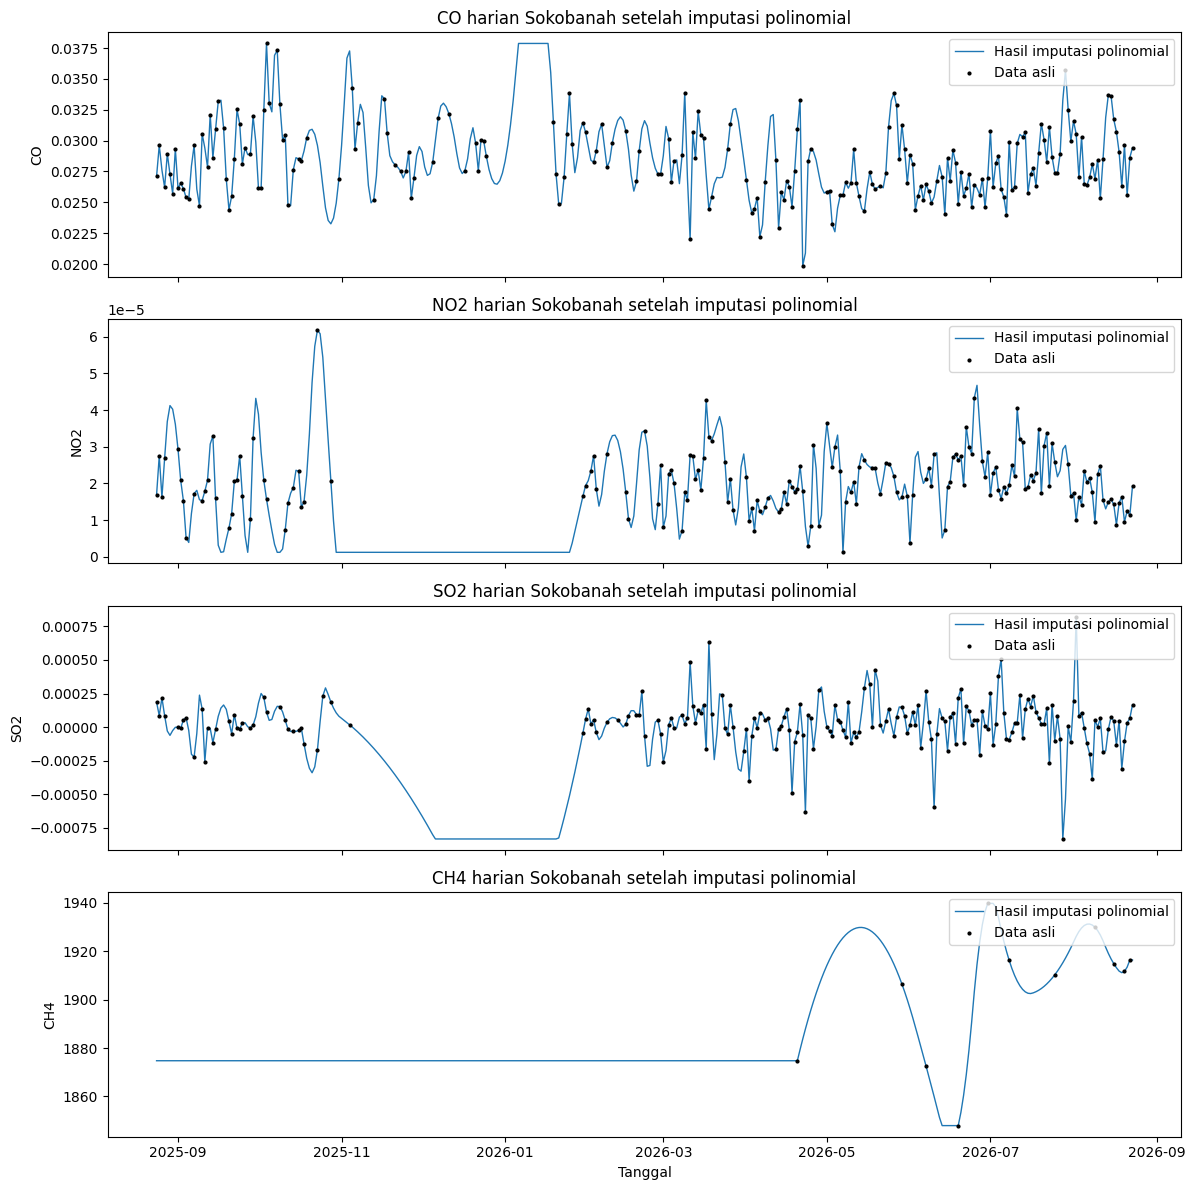

,CO,NO2,SO2,CH4
tanggal,,,,
2025-08-24,0.027113,0.000017,0.000186,1874.744995
2025-08-25,0.029612,0.000028,0.000085,1874.744995
2025-08-26,0.027616,0.000016,0.000218,1874.744995
2025-08-27,0.026210,0.000027,0.000085,1874.744995
2025-08-28,0.028931,0.000037,-0.000029,1874.744995


In [ ]:
ORDER_POLINOMIAL = 2   # derajat polinomial (2 atau 3 umum dipakai)

full_index = pd.date_range(start=start_date, end=end_date, freq="D")
df_raw_idx = df_raw.set_index("tanggal").reindex(full_index)
df_raw_idx.index.name = "tanggal"
missing_sebelum = int(df_raw_idx[POLLUTANS].isna().sum().sum())

df_imputed = df_raw_idx[POLLUTANS].reset_index(drop=True)      # indeks 0..364 (nomor hari)
for pol in POLLUTANS:
    s = df_imputed[pol]
    if s.notna().sum() > ORDER_POLINOMIAL:                       # syarat minimum titik data
        s = s.interpolate(method="polynomial", order=ORDER_POLINOMIAL)
    s = s.ffill().bfill()                                        # hanya menutup ujung deret
    obs = df_raw_idx[pol].dropna()
    df_imputed[pol] = s.clip(lower=obs.min(), upper=obs.max())   # batas fisik dari data asli
df_imputed.index = full_index
df_imputed.index.name = "tanggal"

missing_sesudah = int(df_imputed[POLLUTANS].isna().sum().sum())
print(f"Metode imputasi : polinomial (order={ORDER_POLINOMIAL})")
print(f"Missing sebelum : {missing_sebelum}")
print(f"Missing sesudah : {missing_sesudah}")
print(f"Total baris     : {len(df_imputed)} hari")
for pol in POLLUTANS:
    pct = df_raw_idx[pol].isna().mean() * 100
    if pct > 50:
        print(f"PERINGATAN: {pol} kosong {pct:.0f}% — hasil imputasi kurang dapat diandalkan.")

fig, axes = plt.subplots(len(POLLUTANS), 1, figsize=(12, 3 * len(POLLUTANS)), sharex=True, squeeze=False)
for ax, pol in zip(axes[:, 0], POLLUTANS):
    ax.plot(df_imputed.index, df_imputed[pol], color="tab:blue", lw=1, label="Hasil imputasi polinomial")
    ax.scatter(df_raw_idx.index, df_raw_idx[pol], s=4, color="black", label="Data asli", zorder=3)
    ax.set_title(f"{pol} harian {KECAMATAN} setelah imputasi polinomial")
    ax.set_ylabel(pol)
    ax.legend(loc="upper right")
axes[-1, 0].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()
display(df_imputed.head())

# Dataset inilah yang dipakai untuk ekstraksi fitur (BUKAN hasil imputasi linier)
df_final = df_imputed.copy()

## Langkah 3 — Ekstraksi Fitur TSFEL (365 hari → 1 baris 68 fitur)

Input: **`df_final` = dataset hasil imputasi polinomial**.

Setiap fitur dihitung dengan **fungsi TSFEL asli** (`tsfel.feature_extraction.features.<nama_fitur>`) dengan `fs = 1` (1 sampel per hari) — sama dengan konvensi data rekan (AUC ≈ jumlah nilai harian). Jika TSFEL tidak terpasang, atau satu fungsi gagal, fitur itu dihitung dengan **aproksimasi manual** dan dilaporkan di output (kolom `sumber`).

Fitur yang di TSFEL mengembalikan array (mis. `ecdf`, `mfcc`, `lpcc`, `wavelet_*`) diambil **elemen pertamanya**.

In [ ]:
_trapz = getattr(np, "trapezoid", None) or np.trapz   # kompatibel numpy 1.x dan 2.x
EPS = 1e-12

FITUR_TARGET = [
    "f1_abs_energy","f2_auc","f3_autocorr","f4_average_power","f5_calc_centroid",
    "f6_calc_max","f7_calc_mean","f8_calc_median","f9_calc_min","f10_calc_std",
    "f11_calc_var","f12_dfa","f13_distance","f14_ecdf","f15_ecdf_percentile",
    "f16_ecdf_percentile_count","f17_ecdf_slope","f18_entropy","f19_fundamental_frequency",
    "f20_higuchi_fractal_dimension","f21_hist_mode","f22_human_range_energy","f23_hurst_exponent",
    "f24_interq_range","f25_kurtosis","f26_lempel_ziv","f27_lpcc","f28_max_frequency",
    "f29_max_power_spectrum","f30_maximum_fractal_length","f31_mean_abs_deviation",
    "f32_mean_abs_diff","f33_mean_diff","f34_median_abs_deviation","f35_median_abs_diff",
    "f36_median_diff","f37_median_frequency","f38_mfcc","f39_mse","f40_negative_turning",
    "f41_neighbourhood_peaks","f42_petrosian_fractal_dimension","f43_pk_pk_distance",
    "f44_positive_turning","f45_power_bandwidth","f46_rms","f47_skewness","f48_slope",
    "f49_spectral_centroid","f50_spectral_decrease","f51_spectral_distance","f52_spectral_entropy",
    "f53_spectral_kurtosis","f54_spectral_positive_turning","f55_spectral_roll_off",
    "f56_spectral_roll_on","f57_spectral_skewness","f58_spectral_slope","f59_spectral_spread",
    "f60_spectral_variation","f61_spectrogram_mean_coeff","f62_sum_abs_diff",
    "f63_wavelet_abs_mean","f64_wavelet_energy","f65_wavelet_entropy","f66_wavelet_std",
    "f67_wavelet_var","f68_zero_cross",
]


def _clean_series(series):
    s = pd.Series(series, dtype=float).copy()
    s = s.replace([np.inf, -np.inf], np.nan)
    # Tidak ada interpolasi linier di sini: missing value sudah ditangani imputasi polinomial.
    # Baris di bawah hanya pengaman terakhir terhadap nilai non-finite.
    s = s.fillna(0.0)
    return s.to_numpy(dtype=float)


def _safe_float(value, default=EPS):
    try:
        v = float(value)
    except Exception:
        return float(default)
    if np.isnan(v) or np.isinf(v):
        return float(default)
    return v


def _manual_feature_values(series):
    x = np.asarray(_clean_series(series), dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    n = len(x)
    if n == 0:
        return {k: EPS for k in FITUR_TARGET}

    x_mean = float(np.mean(x))
    x_std = float(np.std(x, ddof=0))
    if abs(x_std) < EPS:
        x_std = EPS
    x_var = float(np.var(x, ddof=0))
    if abs(x_var) < EPS:
        x_var = EPS

    q1, q2, q3 = np.quantile(x, [0.25, 0.5, 0.75])
    iqr_v = float(max(q3 - q1, EPS))
    abs_energy = float(np.sum(x ** 2))
    auc_v = float(_trapz(x, dx=1.0))
    # TSFEL: lag pertama saat autokorelasi ternormalisasi turun di bawah 1/e (bilangan bulat)
    if n > 1:
        xc = x - x_mean
        acf = np.correlate(xc, xc, mode="full")[n - 1:]
        acf = acf / acf[0] if acf[0] != 0 else np.zeros_like(acf)
        di_bawah = np.where(acf < 1 / np.e)[0]
        autocorr = float(di_bawah[0]) if len(di_bawah) else float(n)
    else:
        autocorr = EPS

    avg_power = float(np.mean(x ** 2))
    centroid = float(np.sum(np.arange(n) * x) / max(np.sum(x), EPS)) if np.sum(x) != 0 else EPS
    calc_max = float(np.max(x))
    calc_min = float(np.min(x))
    dfa_v = float(np.std(np.diff(x), ddof=0) / x_std) if n > 1 else EPS
    distance_v = float(np.sum(np.abs(np.diff(x)))) if n > 1 else EPS
    ecdf_q = float(np.quantile(x, 0.5))
    ecdf_count = float(np.sum(x <= ecdf_q))
    slope_v = float(np.polyfit(np.arange(n), x, 1)[0]) if n > 1 else EPS
    if abs(slope_v) < EPS:
        slope_v = EPS

    entropy_val = 0.0
    if np.sum(np.abs(x)) > 0:
        p = np.abs(x) / np.sum(np.abs(x))
        p = p[p > 0]
        entropy_val = float(-np.sum(p * np.log2(p)))
    if abs(entropy_val) < EPS:
        entropy_val = EPS

    fft_vals = np.fft.rfft(x - x_mean)
    freqs = np.fft.rfftfreq(n, d=1.0)
    power = np.abs(fft_vals) ** 2 + EPS
    total_power = float(np.sum(power))
    if total_power <= 0:
        total_power = EPS
    fundamental = float(freqs[np.argmax(power)]) if len(freqs) > 0 else EPS
    max_freq = fundamental
    max_power = float(np.max(power)) if len(power) > 0 else EPS
    spectral_centroid = float(np.sum(freqs * power) / total_power) if len(freqs) > 0 else EPS
    spectral_spread = float(np.sqrt(np.sum(((freqs - spectral_centroid) ** 2) * power) / total_power)) if len(freqs) > 0 else EPS
    p_spec = power / total_power if total_power > 0 else np.ones_like(power) * EPS
    p_spec = p_spec[p_spec > 0]
    spectral_entropy = float(-np.sum(p_spec * np.log2(p_spec))) if len(p_spec) > 0 else EPS
    cum_power = np.cumsum(power)
    if len(freqs) > 0:
        roll_on = float(freqs[min(np.searchsorted(cum_power / cum_power[-1], 0.10), len(freqs)-1)])
        roll_off = float(freqs[min(np.searchsorted(cum_power / cum_power[-1], 0.85), len(freqs)-1)])
    else:
        roll_on = EPS
        roll_off = EPS

    rms_v = float(np.sqrt(np.mean(x ** 2)))
    skew_v = float(pd.Series(x).skew()) if n > 2 else EPS
    kurt_v = float(pd.Series(x).kurt()) if n > 3 else EPS
    mean_abs_dev = float(np.mean(np.abs(x - x_mean)))
    mean_abs_diff = float(np.mean(np.abs(np.diff(x)))) if n > 1 else EPS
    mean_diff = float(np.mean(np.diff(x))) if n > 1 else EPS
    median_abs_dev = float(np.median(np.abs(x - q2)))
    median_abs_diff = float(np.median(np.abs(np.diff(x)))) if n > 1 else EPS
    median_diff = float(np.median(np.diff(x))) if n > 1 else EPS
    median_freq = float(freqs[np.argmin(np.abs(np.cumsum(power) / total_power - 0.5))]) if len(freqs) > 0 else EPS
    mfcc_v = float(np.mean(np.abs(fft_vals))) if len(fft_vals) > 0 else EPS
    mse_v = float(np.mean((x - x_mean) ** 2))
    dx = np.diff(x)
    negative_turning = float(np.sum((dx[:-1] < 0) & (dx[1:] > 0))) if n > 2 else EPS
    neighbourhood_peaks = float(np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))) if n > 2 else EPS
    positive_turning = float(np.sum((dx[:-1] > 0) & (dx[1:] < 0))) if n > 2 else EPS
    pk_pk = float(np.max(x) - np.min(x))
    power_bandwidth = float(np.sum((freqs - spectral_centroid) ** 2 * power) / total_power) if len(freqs) > 0 else EPS
    wavelet_abs_mean = float(np.mean(np.abs(x)))
    wavelet_energy = float(np.sum(x ** 2))
    wavelet_std = float(np.std(x, ddof=0))
    wavelet_var = float(np.var(x, ddof=0))
    zero_cross = float(np.sum(np.diff(np.sign(x)) != 0)) if n > 1 else EPS   # melewati NOL (definisi TSFEL)

    higuchi_fd = float(np.log1p(np.sum(np.abs(np.diff(x))) + EPS) / max(np.log(n), EPS)) if n > 1 else EPS
    cnt, edges = np.histogram(x, bins=10)
    hist_mode = float((edges[np.argmax(cnt)] + edges[np.argmax(cnt) + 1]) / 2)   # NILAI modus, bukan jumlahnya
    hurst_v = float(np.log(np.sum(np.abs(np.diff(x))) + EPS) / max(np.log(n), EPS)) if n > 1 else EPS
    lempel_ziv_v = float(np.sum(np.abs(np.diff(x)))) if n > 1 else EPS
    lpcc_v = float(np.corrcoef(x[:-2], x[2:])[0, 1]) if n > 2 else EPS
    if np.isnan(lpcc_v) or abs(lpcc_v) < EPS:
        lpcc_v = EPS
    maximum_fractal_length = float(np.log1p(np.sum(np.abs(np.diff(x))) + EPS)) if n > 1 else EPS
    petrosian_v = float(np.log10(n + EPS) / (np.log10(n + EPS) + np.log10((n + EPS) / (n + 0.4 * np.sum(np.abs(np.diff(x))) + EPS)))) if n > 1 else EPS
    spectral_decrease = float(np.sum(np.diff(power) / (power[:-1] + EPS))) if len(power) > 1 else EPS
    spectral_distance = float(np.linalg.norm(power - np.mean(power)))
    spectral_kurtosis = float(pd.Series(power).kurt()) if len(power) > 3 else EPS
    spectral_positive_turning = float(np.sum(power > np.mean(power)))
    spectral_skewness = float(pd.Series(power).skew()) if len(power) > 2 else EPS
    spectral_slope = float(np.polyfit(np.arange(len(power)), power, 1)[0]) if len(power) > 1 else EPS
    spectral_variation = float(np.std(power) / max(np.mean(power), EPS))
    spectrogram_mean_coeff = float(np.mean(np.abs(fft_vals))) if len(fft_vals) > 0 else EPS
    wavelet_entropy = entropy_val

    values = {
        "f1_abs_energy": abs_energy,
        "f2_auc": auc_v,
        "f3_autocorr": autocorr,
        "f4_average_power": avg_power,
        "f5_calc_centroid": centroid,
        "f6_calc_max": calc_max,
        "f7_calc_mean": x_mean,
        "f8_calc_median": q2,
        "f9_calc_min": calc_min,
        "f10_calc_std": x_std,
        "f11_calc_var": x_var,
        "f12_dfa": dfa_v,
        "f13_distance": distance_v,
        "f14_ecdf": ecdf_q,
        "f15_ecdf_percentile": ecdf_q,
        "f16_ecdf_percentile_count": ecdf_count,
        "f17_ecdf_slope": slope_v,
        "f18_entropy": entropy_val,
        "f19_fundamental_frequency": fundamental,
        "f20_higuchi_fractal_dimension": higuchi_fd,
        "f21_hist_mode": hist_mode,
        "f22_human_range_energy": float(np.sum(np.abs(x))),
        "f23_hurst_exponent": hurst_v,
        "f24_interq_range": iqr_v,
        "f25_kurtosis": kurt_v,
        "f26_lempel_ziv": lempel_ziv_v,
        "f27_lpcc": lpcc_v,
        "f28_max_frequency": max_freq,
        "f29_max_power_spectrum": max_power,
        "f30_maximum_fractal_length": maximum_fractal_length,
        "f31_mean_abs_deviation": mean_abs_dev,
        "f32_mean_abs_diff": mean_abs_diff,
        "f33_mean_diff": mean_diff,
        "f34_median_abs_deviation": median_abs_dev,
        "f35_median_abs_diff": median_abs_diff,
        "f36_median_diff": median_diff,
        "f37_median_frequency": median_freq,
        "f38_mfcc": mfcc_v,
        "f39_mse": mse_v,
        "f40_negative_turning": negative_turning,
        "f41_neighbourhood_peaks": neighbourhood_peaks,
        "f42_petrosian_fractal_dimension": petrosian_v,
        "f43_pk_pk_distance": pk_pk,
        "f44_positive_turning": positive_turning,
        "f45_power_bandwidth": power_bandwidth,
        "f46_rms": rms_v,
        "f47_skewness": skew_v,
        "f48_slope": slope_v,
        "f49_spectral_centroid": spectral_centroid,
        "f50_spectral_decrease": spectral_decrease,
        "f51_spectral_distance": spectral_distance,
        "f52_spectral_entropy": spectral_entropy,
        "f53_spectral_kurtosis": spectral_kurtosis,
        "f54_spectral_positive_turning": spectral_positive_turning,
        "f55_spectral_roll_off": roll_off,
        "f56_spectral_roll_on": roll_on,
        "f57_spectral_skewness": spectral_skewness,
        "f58_spectral_slope": spectral_slope,
        "f59_spectral_spread": spectral_spread,
        "f60_spectral_variation": spectral_variation,
        "f61_spectrogram_mean_coeff": spectrogram_mean_coeff,
        "f62_sum_abs_diff": distance_v,
        "f63_wavelet_abs_mean": wavelet_abs_mean,
        "f64_wavelet_energy": wavelet_energy,
        "f65_wavelet_entropy": wavelet_entropy,
        "f66_wavelet_std": wavelet_std,
        "f67_wavelet_var": wavelet_var,
        "f68_zero_cross": zero_cross,
    }
    return {k: _safe_float(v, EPS) for k, v in values.items()}




FS = 1.0   # frekuensi sampling: 1 sampel/hari


def _clean_series(series):
    s = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    # Tidak ada interpolasi linier di sini: missing value sudah ditangani imputasi polinomial.
    return s.fillna(0.0).to_numpy(dtype=float)


def _ke_skalar(v):
    arr = np.asarray(v, dtype=float).ravel()
    if arr.size == 0 or not np.isfinite(arr[0]):
        return None
    return float(arr[0])


def ekstrak_fitur_68(series, fs=FS):
    """Mengembalikan (DataFrame 1 baris x 68 kolom, dict sumber per fitur)."""
    x = _clean_series(series)
    manual = _manual_feature_values(x)
    nilai, sumber = {}, {}
    for kolom in FITUR_TARGET:
        nama = kolom.split("_", 1)[1]
        v = None
        if tsfel_features is not None and hasattr(tsfel_features, nama):
            try:
                fn = getattr(tsfel_features, nama)
                kw = {"fs": fs} if "fs" in inspect.signature(fn).parameters else {}
                v = _ke_skalar(fn(x, **kw))
            except Exception:
                v = None
        if v is None:
            nilai[kolom], sumber[kolom] = manual[kolom], "manual"
        else:
            nilai[kolom], sumber[kolom] = v, "tsfel"
    return pd.DataFrame([nilai], columns=FITUR_TARGET, dtype=float), sumber


output_dir = os.path.join(os.getcwd(), "output_features")
os.makedirs(output_dir, exist_ok=True)

baris_fitur, laporan_sumber = {}, {}
for pol in POLLUTANS:
    df_row, sumber = ekstrak_fitur_68(df_final[pol].values)
    baris_fitur[pol] = df_row.iloc[0]
    laporan_sumber[pol] = sumber
    n_tsfel = sum(v == "tsfel" for v in sumber.values())
    path = os.path.join(output_dir, f"{pol}_features_tsfel.csv")
    try:
        df_row.to_csv(path, index=False, float_format="%.15g")
    except PermissionError:                                   # file terkunci (Excel/OneDrive di Windows)
        path = os.path.join(output_dir, f"{pol}_features_tsfel_{int(time.time())}.csv")
        df_row.to_csv(path, index=False, float_format="%.15g")
    print(f"[{pol}] {n_tsfel}/68 fitur dari TSFEL asli, {68 - n_tsfel} manual -> {path}")

if tsfel_features is None:
    print("\nPERINGATAN: TSFEL asli tidak aktif. Beberapa fitur (fraktal, wavelet, spektral, dll.) hanya aproksimasi "
          "dan TIDAK sebanding dengan data rekan. Pasang dengan: pip install tsfel")

df_fitur_sokobanah = pd.DataFrame(baris_fitur).T
df_fitur_sokobanah.index.name = "polutan"
display(df_fitur_sokobanah.iloc[:, :8])

/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)
/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)
/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


[CO] 63/68 fitur dari TSFEL asli, 5 manual -> /content/output_features/CO_features_tsfel.csv
[NO2] 62/68 fitur dari TSFEL asli, 6 manual -> /content/output_features/NO2_features_tsfel.csv
[SO2] 63/68 fitur dari TSFEL asli, 5 manual -> /content/output_features/SO2_features_tsfel.csv
[CH4] 62/68 fitur dari TSFEL asli, 6 manual -> /content/output_features/CH4_features_tsfel.csv


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
polutan,,,,,,,,
CO,3.069357e-01,10.487684,4.0,8.432299e-04,177.459335,0.037869,0.028811,0.028424
NO2,1.517282e-07,0.005898,7.0,4.168357e-10,193.916293,0.000062,0.000016,0.000017
SO2,4.928976e-05,0.083757,34.0,1.354114e-07,145.647546,0.000822,-0.000130,-0.000010
CH4,1.298272e+09,686443.921520,17.0,3.566681e+06,183.477375,1939.684204,1885.861519,1874.744995


## Langkah 4 — Analisis Kemiripan Pola Antar Kuartal

Data 365 hari dibagi 4 kuartal (±91 hari), tiap kuartal diekstrak fiturnya dengan fungsi yang sama seperti Langkah 3, lalu dihitung **cosine similarity** dan **korelasi Pearson** antar kuartal. Polutan yang dianalisis adalah **CO** (jika ada di data).

## Dokumentasi Lengkap Fitur TSFEL

Bagian ini merangkum **definisi, cara kerja, cara menghitung, rumus, dan makna** dari fitur-fitur utama yang diekstraksi TSFEL, dikelompokkan menurut 3 domain (Statistik, Temporal, Spektral), mengikuti gaya penjelasan pada slide `Ekstraksi_Fitur_TSFEL.pptx`. Fitur-fitur lain yang tidak dibahas satu per satu di sini (misalnya varian FFT-coefficient per indeks, wavelet, atau histogram) mengikuti prinsip domain yang sama dan bisa dicek langsung dari nama kolomnya di `df_fitur_sokobanah`.

> Jika ada bagian yang masih belum dipahami setelah membaca dokumentasi ini, silakan dicatat dan ditanyakan pada pertemuan/minggu depan.

---

### 1. Domain Statistik

#### **Mean**
- **Definisi**: Nilai rata-rata konsentrasi CO selama periode yang diamati (365 hari untuk fitur tahunan, ±91 hari untuk fitur per kuartal).
- **Cara Kerja & Menghitung**: Seluruh nilai CO harian dijumlahkan lalu dibagi jumlah observasi $N$.
- **Rumus**: $\mu = \dfrac{1}{N} \sum_{i=1}^{N} x_i$
- **Makna**: Baseline rata-rata paparan polusi CO di kecamatan tersebut pada periode itu.

#### **Variance**
- **Definisi**: Ukuran penyebaran kuadrat data CO di sekitar nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Menghitung kuadrat selisih tiap data harian terhadap mean, lalu dirata-ratakan.
- **Rumus**: $\sigma^2 = \dfrac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$
- **Makna**: Mengukur stabilitas/fluktuasi konsentrasi polutan harian — makin besar, makin fluktuatif.

#### **Standard Deviation**
- **Definisi**: Akar kuadrat varians, mengukur sebaran data dalam satuan asli (bukan kuadrat).
- **Cara Kerja & Menghitung**: Menarik akar kuadrat dari hasil perhitungan varians.
- **Rumus**: $\sigma = \sqrt{\sigma^2}$
- **Makna**: Seberapa jauh kondisi CO harian menyimpang dari rata-rata periode tersebut, dalam satuan yang sama dengan data asli.

#### **Skewness**
- **Definisi**: Ukuran ketidaksimetrisan (kemencengan) distribusi konsentrasi CO.
- **Cara Kerja & Menghitung**: Menghitung momen ketiga terstandardisasi dari data.
- **Rumus**: $\gamma_1 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^3}{\sigma^3}$
- **Makna**: Skewness positif menandakan ada beberapa hari dengan lonjakan polusi ekstrem yang menarik ekor distribusi ke kanan.

#### **Kurtosis**
- **Definisi**: Derajat keruncingan dan ketebalan ekor distribusi data CO.
- **Cara Kerja & Menghitung**: Menghitung momen keempat terstandardisasi.
- **Rumus**: $\beta_2 = \dfrac{\frac{1}{N}\sum (x_i-\mu)^4}{\sigma^4}$
- **Makna**: Kurtosis tinggi berarti variabilitas polusi didominasi lonjakan singkat bernilai ekstrem, bukan fluktuasi merata.

#### **Root Mean Square (RMS)**
- **Definisi**: Akar rata-rata kuadrat dari magnitudo sinyal CO (lihat contoh manual di slide: X=[2,-1,3,-2,4] → RMS ≈ 2.61).
- **Cara Kerja & Menghitung**: Kuadratkan tiap nilai harian → rata-ratakan → tarik akar kuadrat.
- **Rumus**: $x_{rms} = \sqrt{\dfrac{1}{N}\sum_{i=1}^{N} x_i^2}$
- **Makna**: Merepresentasikan besarnya "energi" atau intensitas beban polusi secara keseluruhan pada periode itu.

#### **Interquartile Range (IQR sebagai fitur)**
- **Definisi**: Selisih antara kuartil atas $Q_3$ dan kuartil bawah $Q_1$ dari data pada window tersebut.
- **Cara Kerja & Menghitung**: Urutkan data, tentukan posisi persentil ke-75 dan ke-25, hitung selisihnya.
- **Rumus**: $IQR = Q_3 - Q_1$
- **Makna**: Sebaran 50% data tengah, tidak terpengaruh nilai ekstrem — ukuran sebaran yang sama dengan dasar metode IQR untuk deteksi outlier.

#### **Absolute Energy**
- **Definisi**: Akumulasi total kuadrat nilai sinyal CO.
- **Cara Kerja & Menghitung**: Jumlahkan kuadrat seluruh nilai CO harian pada window tersebut.
- **Rumus**: $E = \sum_{i=1}^{N} x_i^2$
- **Makna**: Total beban kuantitatif akumulasi CO yang "diterima" lingkungan pada periode tersebut.

#### **Mean Absolute Deviation (MAD, versi statistik)**
- **Definisi**: Rata-rata jarak mutlak setiap data harian terhadap nilai rata-ratanya.
- **Cara Kerja & Menghitung**: Jumlahkan nilai absolut selisih tiap titik terhadap mean, bagi $N$.
- **Rumus**: $MAD = \dfrac{1}{N}\sum_{i=1}^{N} |x_i - \mu|$
- **Makna**: Mengukur variabilitas harian dengan cara yang lebih tahan terhadap outlier dibanding standar deviasi.

#### **ECDF / Quantiles (0.1, 0.25, 0.5, 0.75, 0.9)**
- **Definisi**: Nilai ambang pada persentil tertentu dari fungsi distribusi kumulatif empiris data CO.
- **Cara Kerja & Menghitung**: Urutkan data dari terkecil ke terbesar, ambil titik potong pada persentil terkait.
- **Rumus**: $P(X \le x_p) = p$
- **Makna**: Quantile 0.5 (median) menunjukkan titik tengah polusi; quantile 0.9 menggambarkan kondisi 10% hari terburuk pada periode tersebut.

---

### 2. Domain Temporal

#### **Autocorrelation**
- **Definisi**: Korelasi sinyal CO terhadap dirinya sendiri dengan jeda waktu $k$ hari.
- **Cara Kerja & Menghitung**: Membandingkan deret $x_t$ dengan deret yang sama namun digeser $k$ hari ($x_{t+k}$).
- **Rumus**: $R(k) = \dfrac{\sum_{t=1}^{N-k}(x_t-\mu)(x_{t+k}-\mu)}{\sum_{t=1}^{N}(x_t-\mu)^2}$
- **Makna**: Mengukur "memori" udara — autokorelasi lag-1 tinggi berarti polusi hari ini sangat mirip dengan hari kemarin.

#### **Zero Crossing Rate (ZCR)**
- **Definisi**: Banyaknya deret waktu melewati nilai nol (perubahan tanda) (lihat contoh manual di slide: X=[2,-1,3,-2,4] → 4 transisi).
- **Cara Kerja & Menghitung**: Menghitung berapa kali terjadi perubahan tanda pada $(x_t - \mu)$.
- **Rumus**: $ZCR = \dfrac{1}{N-1}\sum_{t=1}^{N-1} \mathbb{1}\big[(x_t-\mu)(x_{t+1}-\mu) < 0\big]$
- **Makna**: Menggambarkan seberapa sering kondisi udara berpindah dari "di bawah rata-rata" ke "di atas rata-rata" atau sebaliknya.

#### **Mean Absolute Differences**
- **Definisi**: Rata-rata perubahan mutlak CO dari satu hari ke hari berikutnya (lihat contoh manual di slide: X=[2,-1,3,-2,4] → MAD = 4.5).
- **Cara Kerja & Menghitung**: Jumlahkan nilai mutlak selisih antar hari berturut-turut, bagi $N-1$.
- **Rumus**: $\dfrac{1}{N-1}\sum_{t=1}^{N-1} |x_{t+1}-x_t|$
- **Makna**: Menunjukkan seberapa cepat/volatil perubahan kondisi udara harian.

#### **Peak Detection**
- **Definisi**: Jumlah puncak lokal (local maxima) pada deret waktu.
- **Cara Kerja & Menghitung**: Menghitung titik di mana $x_t > x_{t-1}$ dan $x_t > x_{t+1}$, opsional melebihi ambang tertentu.
- **Makna**: Menunjukkan seberapa sering terjadi lonjakan singkat pencemaran CO pada periode tersebut.

#### **Temporal Centroid**
- **Definisi**: "Pusat gravitasi waktu" dari sinyal CO — kapan (di titik waktu mana) sebagian besar "bobot" konsentrasi terkumpul.
- **Cara Kerja & Menghitung**: Rata-rata tertimbang indeks waktu, dengan bobot = nilai CO itu sendiri.
- **Rumus**: $Centroid = \dfrac{\sum_{t=1}^{N} t \cdot x_t}{\sum_{t=1}^{N} x_t}$
- **Makna**: Menunjukkan pada periode mana (awal/akhir window) konsentrasi CO cenderung lebih terkonsentrasi.

#### **Slope (Linear Trend)**
- **Definisi**: Kemiringan garis lurus hasil regresi linear terhadap deret waktu.
- **Cara Kerja & Menghitung**: Fit garis $y = m \cdot t + c$ dengan metode kuadrat terkecil (least squares).
- **Rumus**: $m = \dfrac{N\sum(t \cdot x_t) - \sum t \sum x_t}{N \sum t^2 - (\sum t)^2}$
- **Makna**: Kemiringan positif ($m>0$) menunjukkan CO cenderung meningkat sepanjang periode tersebut; negatif berarti menurun.

#### **Area Under Curve (AUC)**
- **Definisi**: Luas daerah di bawah kurva grafik deret waktu CO.
- **Cara Kerja & Menghitung**: Aturan integrasi trapesium pada deret waktu.
- **Rumus**: $AUC = \sum_{t=1}^{N-1} \dfrac{x_t + x_{t+1}}{2}$
- **Makna**: Total paparan akumulatif CO sepanjang periode tersebut.

---

### 3. Domain Spektral (berbasis FFT)

Semua fitur di domain ini bekerja dengan cara yang sama: sinyal CO 365 harian pertama-tama ditransformasikan ke domain frekuensi memakai **Fast Fourier Transform (FFT)** — memecah gelombang naik-turun konsentrasi CO yang kompleks menjadi kumpulan gelombang sinus/kosinus sederhana dengan frekuensi & magnitudo berbeda (lihat konsep DFT di slide 14–19).

#### **Spectral Centroid**
- **Definisi**: "Pusat gravitasi" frekuensi dari spektrum sinyal (lihat contoh manual di slide: Magnitudo=[3,1,3,1] → Centroid = 1.25).
- **Cara Kerja & Menghitung**: Transformasi FFT, lalu rata-rata frekuensi tertimbang oleh daya spektralnya.
- **Rumus**: $f_c = \dfrac{\sum f \cdot P(f)}{\sum P(f)}$
- **Makna**: Apakah variasi CO didominasi fluktuasi jangka panjang (frekuensi rendah/musiman) atau perubahan harian yang cepat (frekuensi tinggi).

#### **Spectral Spread**
- **Definisi**: Standar deviasi dari spektrum frekuensi di sekitar spectral centroid (lihat contoh manual di slide: SC=1.25 → Spread ≈ 1.089).
- **Cara Kerja & Menghitung**: Momen kedua spektral terhadap pusat spektrum (mirip varians, tapi di domain frekuensi).
- **Rumus**: $Spread = \sqrt{\dfrac{\sum (f-f_c)^2 P(f)}{\sum P(f)}}$
- **Makna**: Menunjukkan seberapa lebar rentang frekuensi yang berkontribusi pada dinamika emisi CO.

#### **Fundamental Frequency**
- **Definisi**: Frekuensi dasar dengan magnitudo spektral tertinggi.
- **Cara Kerja & Menghitung**: Mengidentifikasi puncak tertinggi pada spektrum daya hasil FFT.
- **Rumus**: $f_0 = \arg\max_f P(f)$
- **Makna**: Mengungkap siklus alami polusi CO yang paling dominan (misalnya siklus mingguan akibat lalu lintas, atau siklus musiman).

#### **Spectral Entropy**
- **Definisi**: Ukuran keacakan distribusi daya frekuensi sinyal CO, mengadopsi entropi Shannon (lihat contoh manual di slide: p=[0.45,0.05,0.45,0.05] → entropi ≈ 1.469 bit).
- **Cara Kerja & Menghitung**: Normalisasi spektrum daya menjadi distribusi probabilitas $p(f)$, lalu hitung entropi Shannon-nya.
- **Rumus**: $H = -\sum p(f)\log_2 p(f)$, dengan $p(f) = \dfrac{P(f)}{\sum P(f)}$
- **Makna**: Entropi tinggi → pola variasi CO kompleks/acak; entropi rendah → ada pola periodik/musiman yang cukup teratur.


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features.py:1820: UserWarning: The fractal features will not be calculated and will be replaced with 'nan' because the length of the input signal is smaller than the required minimum of 160 data points.
  warnings.warn(warning_msg, UserWarning)


Polutan: CO | kolom konstan dibuang: 5 | kolom dipakai: 63


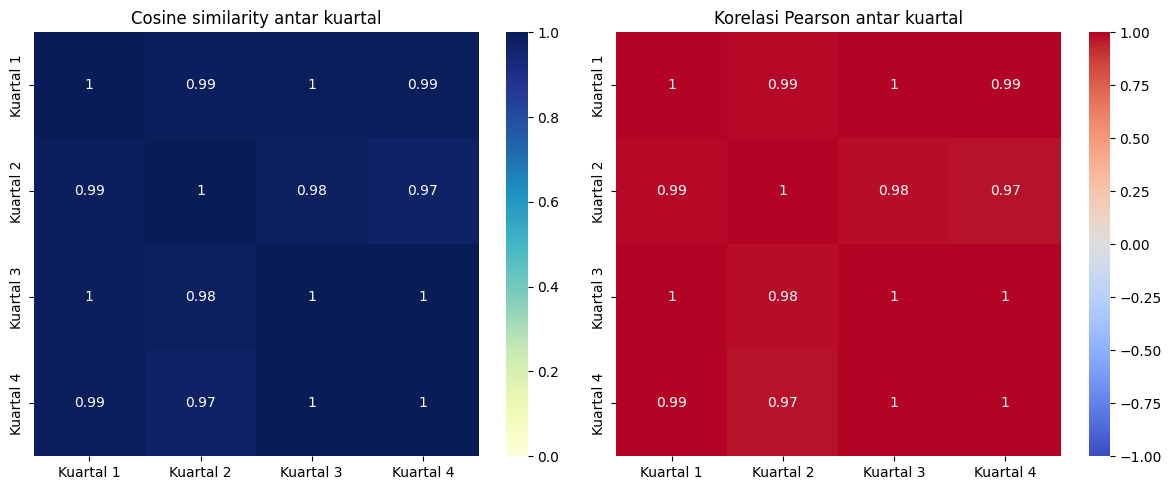

Rata-rata CO per kuartal:
- Kuartal 1: 0.02916
- Kuartal 2: 0.03049
- Kuartal 3: 0.02736
- Kuartal 4: 0.02823


In [ ]:
POL_KUARTAL = "CO" if "CO" in df_final.columns else df_final.columns[0]

kuartal_arrays = np.array_split(df_final[POL_KUARTAL].values, 4)
nama_kuartal = [f"Kuartal {i + 1}" for i in range(4)]

df_fitur_kuartal = pd.concat(
    [ekstrak_fitur_68(arr)[0].set_axis([nama]) for arr, nama in zip(kuartal_arrays, nama_kuartal)], axis=0)

kolom_konstan = df_fitur_kuartal.columns[df_fitur_kuartal.std(axis=0) == 0]
df_kuartal_bersih = df_fitur_kuartal.drop(columns=kolom_konstan)
print(f"Polutan: {POL_KUARTAL} | kolom konstan dibuang: {len(kolom_konstan)} | kolom dipakai: {df_kuartal_bersih.shape[1]}")

df_cos_sim = pd.DataFrame(cosine_similarity(df_kuartal_bersih.values), index=nama_kuartal, columns=nama_kuartal)
df_pearson = df_kuartal_bersih.T.corr(method="pearson")
df_pearson.index = df_pearson.columns = nama_kuartal

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(df_cos_sim, annot=True, cmap="YlGnBu", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Cosine similarity antar kuartal")
sns.heatmap(df_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Pearson antar kuartal")
plt.tight_layout()
plt.show()

print(f"Rata-rata {POL_KUARTAL} per kuartal:")
for nama, arr in zip(nama_kuartal, kuartal_arrays):
    print(f"- {nama}: {arr.mean():.5f}")

## Ringkasan

- Polutan: **CO, NO2, SO2, CH4**, Kecamatan **Sokobanah**, data **citra satelit Sentinel-5P asli** (tanpa simulasi).
- Missing value: **imputasi polinomial** (ffill/bfill hanya di ujung deret) — imputasi linier tidak dipakai lagi.
- Ekstraksi fitur: **68 fitur TSFEL** dari dataset hasil imputasi polinomial, memakai fungsi TSFEL asli (`fs=1`); fallback manual hanya jika TSFEL tidak ada.
- Outlier: **K-Means** pada tabel fitur seluruh anggota (Python sebagai pengecekan awal, KNIME sebagai hasil resmi). PyOD CBLOF dipakai sebagai pembanding bila terpasang.
- Pemeriksaan kualitas data rekan dilakukan sebelum K-Means; nilai mustahil ditandai, tidak dihapus.